In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
iris = load_iris()
X = iris.data                # features (sepal/petal measurements)
y = iris.target              # target classes (0,1,2)
class_names = iris.target_names

print("Feature names:", iris.feature_names)
print("Target classes:", class_names)
print("Dataset shape:", X.shape)


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 120, Test samples: 30


In [5]:
# 3. TRAIN A CLASSIFIER (Logistic Regression)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [6]:
# 4. MAKE PREDICTIONS ON TEST SET
y_pred = model.predict(X_test)


In [7]:
# 5. EVALUATE ACCURACY
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on test set: {accuracy:.2%}")


Accuracy on test set: 100.00%


In [8]:

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(conf_matrix, index=class_names, columns=class_names))


Confusion Matrix:
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          0
virginica        0           0         11


In [9]:
# 6. PREDICT A SINGLE NEW SAMPLE (for demonstration)
new_sample = [[5.1, 3.5, 1.4, 0.2]]   # typical Setosa measurements
predicted_class = model.predict(new_sample)[0]
print(f"\nPrediction for {new_sample}: {class_names[predicted_class]}")



Prediction for [[5.1, 3.5, 1.4, 0.2]]: setosa


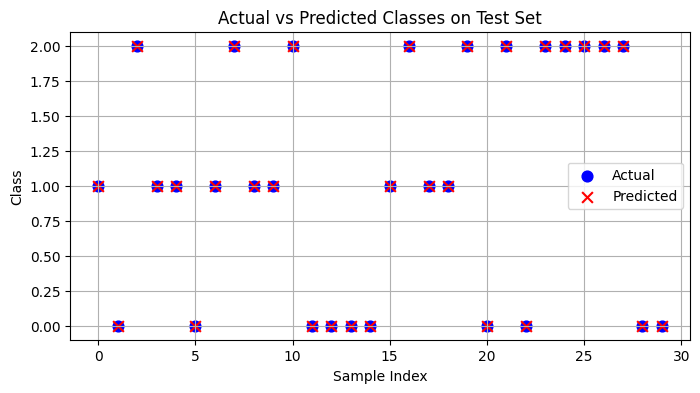

In [11]:
# 7. VISUALIZE ACTUAL vs PREDICTED (simple scatter plot)
plt.figure(figsize=(8,4))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', marker='o', s=60)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', marker='x', s=60)
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Actual vs Predicted Classes on Test Set')
plt.legend()
plt.grid(True)
plt.show()
